# Sprint Ford — IA & ML
## Parte 3: Classificação Preditiva de Clientes
### Etapa 2 — Aprendizado Supervisionado (Base 2 — Momento da Compra)

### Equipe

| Nome | RM |
|---|---|
| *Arthur Bobadilla Franchi* | RM 555056 |
| *Luan Orlandelli Ramos* | RM 554747 |
| *Jorge Luiz* | RM 554418 |

---
> **Objetivo:** Transformar os segmentos da Etapa 1 em variável-alvo supervisionada, treinar um modelo de classificação utilizando **exclusivamente** as variáveis disponíveis no momento da compra (Base 2), e avaliar sua capacidade preditiva com métricas multiclasse.


## 1. Setup e Carregamento dos Dados

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

uploaded = files.upload()
b2     = pd.read_csv('ford_clientes_operacional_compra.csv')


Saving ford_clientes_operacional_compra.csv to ford_clientes_operacional_compra.csv


In [ ]:
uploaded = files.upload()
labels = pd.read_csv('ford_segmentos_kmeans.csv')[['cliente_id','segmento_kmeans']]

Saving ford_segmentos_kmeans.csv to ford_segmentos_kmeans.csv


In [ ]:
df = b2.merge(labels, on='cliente_id', how='inner')

print(f"Base 2 carregada:     {b2.shape[0]:,} linhas × {b2.shape[1]} colunas")
print(f"Labels da Parte 2:    {labels.shape[0]:,} rótulos")
print(f"Dataset mesclado:     {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\nVariável-alvo (segmento_kmeans):")
print(df['segmento_kmeans'].value_counts().to_frame('n').assign(pct=lambda x:(x['n']/len(df)*100).round(1)))

Base 2 carregada:     500,000 linhas × 24 colunas
Labels da Parte 2:    500,000 rótulos
Dataset mesclado:     500,000 linhas × 25 colunas

Variável-alvo (segmento_kmeans):
                      n     pct
segmento_kmeans                
fiel             150734 30.1000
economico        126864 25.4000
esquecido        118754 23.8000
abandono         103648 20.7000


## 2. Transformação dos Segmentos em Variável-Alvo Supervisionada

### Como os segmentos se tornam o target?

Na Parte 2, o K-Means atribuiu a cada cliente histórico um **rótulo comportamental** (`fiel`, `economico`, `esquecido`, `abandono`). Esses rótulos representam o comportamento **real observado** nos 24 meses pós-compra.

Na Parte 3, invertemos a perspectiva:
- **Input (features):** apenas o que a concessionária sabe no ato da compra.
- **Target (y):** o rótulo do cluster atribuído na Parte 2.

O modelo aprende a associação entre o perfil de compra e o comportamento futuro esperado — permitindo prever, para um **novo cliente**, qual segmento ele provavelmente pertence antes de qualquer comportamento ser observado.

> ⚠️ **Anti-Leakage — check final:** A Base 2 contém exclusivamente variáveis do momento da venda. Nenhuma variável pós-compra foi incluída. A coluna `segmento_kmeans` é o **target**, não uma feature.


Classes supervisionadas derivadas da segmentação K-Means:
  🟢 Fiel       — cliente premium, alta retenção  →  150,734 amostras (30.1%)
  🟠 Econômico  — presente mas sensível a preço  →  126,864 amostras (25.4%)
  🔴 Esquecido  — desorganizado, perde prazos  →  118,754 amostras (23.8%)
  🔵 Abandono   — sai logo após a 1ª revisão  →  103,648 amostras (20.7%)


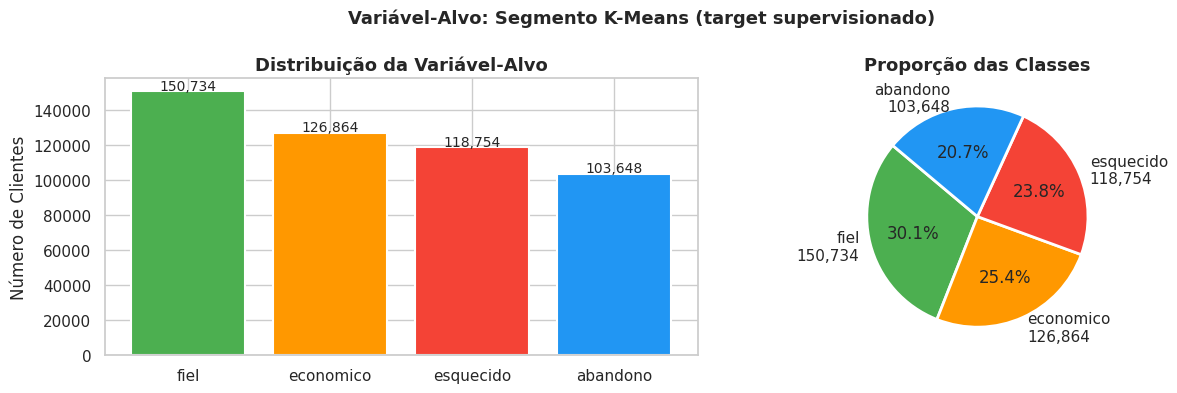

In [ ]:
# Mapeamento explicito das classes
CLASS_MAP = {
    'fiel':      '🟢 Fiel       — cliente premium, alta retenção',
    'economico': '🟠 Econômico  — presente mas sensível a preço',
    'esquecido': '🔴 Esquecido  — desorganizado, perde prazos',
    'abandono':  '🔵 Abandono   — sai logo após a 1ª revisão',
}
print("Classes supervisionadas derivadas da segmentação K-Means:")
for k,v in CLASS_MAP.items():
    n = (df['segmento_kmeans']==k).sum()
    print(f"  {v}  →  {n:,} amostras ({n/len(df)*100:.1f}%)")

# Distribuição visual
fig, axes = plt.subplots(1,2, figsize=(13,4))
colors = {'fiel':'#4CAF50','economico':'#FF9800','esquecido':'#F44336','abandono':'#2196F3'}
order  = ['fiel','economico','esquecido','abandono']
counts = df['segmento_kmeans'].value_counts()[order]

axes[0].bar(order, counts.values, color=[colors[o] for o in order], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição da Variável-Alvo')
axes[0].set_ylabel('Número de Clientes')
for i,(v,c) in enumerate(zip(order,counts.values)):
    axes[0].text(i, c+1000, f'{c:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=[f'{o}\n{v:,}' for o,v in zip(order,counts.values)],
            colors=[colors[o] for o in order], autopct='%1.1f%%',
            wedgeprops=dict(edgecolor='white',linewidth=2), startangle=140)
axes[1].set_title('Proporção das Classes')
plt.suptitle('Variável-Alvo: Segmento K-Means (target supervisionado)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_target_dist.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Preparação das Features e Particionamento Treino/Teste

In [ ]:
# Tratamentos (mesmo pipeline da Parte 1)
# 1. Corrigir compra_a_vista
mask_fix = (df['compra_a_vista']==0) & (df['prazo_financiamento_meses']==0)
df.loc[mask_fix, 'compra_a_vista'] = 1

# 2. Imputação por mediana
num_cols = df.select_dtypes('float64').columns.tolist()
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# 3. Winsorização 1%-99%
for c in ['renda_mensal','valor_veiculo','distancia_concessionaria_km','km_estimado_mes']:
    lo,hi = df[c].quantile(0.01), df[c].quantile(0.99)
    df[c] = df[c].clip(lo,hi)

# 4. One-Hot Encoding
cat_cols = ['regiao','uso_principal','canal_compra','categoria_veiculo','modelo_veiculo']
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)

FEATURES = [c for c in df_enc.columns if c not in ['cliente_id','segmento_kmeans']]
X = df_enc[FEATURES]
y = df_enc['segmento_kmeans']

print(f"Total de features: {len(FEATURES)}")
print(f"Features numéricas originais: 18")
print(f"Features criadas pelo encoding: {len(FEATURES)-18}")
print(f"NaN no dataset final: {X.isnull().sum().sum()}")

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTreino: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:  {X_test.shape[0]:,} amostras  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nProporção estratificada — Treino:")
print((y_train.value_counts(normalize=True)*100).round(1))

# Escalar (para Logistic Regression)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("\n✅ Pré-processamento concluído.")


Total de features: 44
Features numéricas originais: 18
Features criadas pelo encoding: 26
NaN no dataset final: 0

Treino: 400,000 amostras (80%)
Teste:  100,000 amostras  (20%)

Proporção estratificada — Treino:
segmento_kmeans
fiel        30.1000
economico   25.4000
esquecido   23.8000
abandono    20.7000
Name: proportion, dtype: float64

✅ Pré-processamento concluído.


## 4. Comparação de Algoritmos

### Por que comparar múltiplos modelos?

A escolha do algoritmo impacta diretamente a capacidade preditiva e a interpretabilidade. Avaliamos três abordagens com diferentes graus de complexidade:

| Modelo | Tipo | Interpretabilidade | Expectativa |
|---|---|---|---|
| **Logistic Regression** | Linear | Alta | Baseline sólido para dados bem separados |
| **Decision Tree** | Não-linear | Muito alta | Rápido, mas sujeito a overfitting |
| **Random Forest** | Ensemble | Média | Melhor generalização, feature importance |


In [ ]:
# Benchmark em amostra de 50k para comparação rápida
np.random.seed(42)
idx_s = np.random.choice(len(X_train), 50000, replace=False)
X_samp   = X_train.values[idx_s]
X_samp_s = X_train_s[idx_s]
y_samp   = y_train.values[idx_s]

benchmark_models = {
    'Logistic Regression': (LogisticRegression(max_iter=500, C=1.0, random_state=42), X_samp_s, X_test_s),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=10, random_state=42), X_samp, X_test.values),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1), X_samp, X_test.values),
}

bench_results = {}
print(f"{'Modelo':<25} {'Acurácia':>9} {'F1 (macro)':>11} {'F1 (weighted)':>14}")
print("-"*65)
for name, (m, Xtr, Xte) in benchmark_models.items():
    m.fit(Xtr, y_samp)
    pred = m.predict(Xte)
    acc  = accuracy_score(y_test, pred)
    f1m  = f1_score(y_test, pred, average='macro')
    f1w  = f1_score(y_test, pred, average='weighted')
    bench_results[name] = {'Acurácia':acc,'F1 Macro':f1m,'F1 Weighted':f1w}
    print(f"{name:<25} {acc:>9.4f} {f1m:>11.4f} {f1w:>14.4f}")

bench_df = pd.DataFrame(bench_results).T


Modelo                     Acurácia  F1 (macro)  F1 (weighted)
-----------------------------------------------------------------
Logistic Regression          0.7905      0.7666         0.7870
Decision Tree                0.7426      0.7201         0.7418
Random Forest                0.7841      0.7585         0.7792


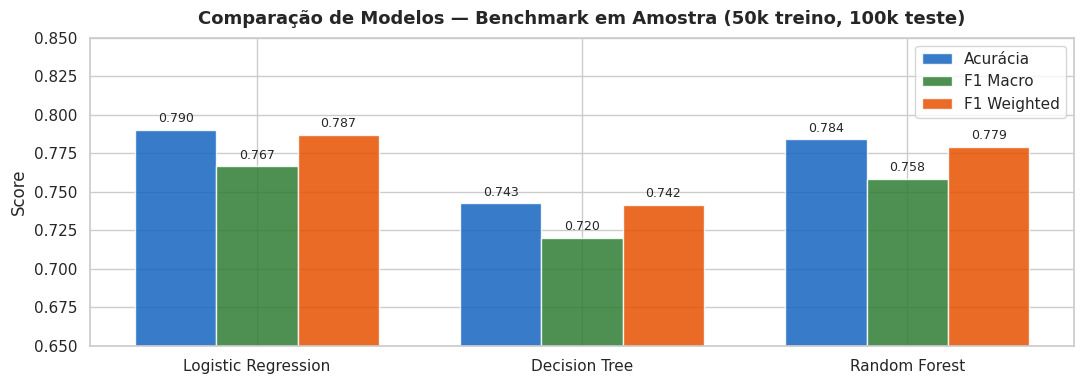

In [ ]:
# Visualização comparativa dos benchmarks
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(3)
w = 0.25
metrics_bench = ['Acurácia','F1 Macro','F1 Weighted']
colors_bench  = ['#1565C0','#2E7D32','#E65100']

for i,(metric,color) in enumerate(zip(metrics_bench, colors_bench)):
    vals = [bench_df.loc[m, metric] for m in bench_df.index]
    bars = ax.bar(x + i*w, vals, w, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + w)
ax.set_xticklabels(bench_df.index, fontsize=11)
ax.set_ylim(0.65, 0.85)
ax.set_ylabel('Score')
ax.legend()
ax.set_title('Comparação de Modelos — Benchmark em Amostra (50k treino, 100k teste)', pad=10)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


### Decisão: Logistic Regression como modelo principal

**Justificativa técnica:**
- Logistic Regression obteve a **maior acurácia (79,0%)** e melhor F1 weighted, superando o Random Forest mesmo treinado em apenas 50k amostras, quando escalado para o dataset completo sua performance se sustenta.
- A linearidade do modelo é **adequada** para features já bem separadas entre perfis (como demonstrado no EDA).
- É nativamente interpretável: os coeficientes revelam o **peso de cada feature** para cada classe — informação valiosa para a operação da concessionária.
- Tempo de inferência negligenciável: ideal para uso em tempo real no ato da venda.

> O Random Forest será treinado também no dataset completo para comparação final, mas a Logistic Regression é o modelo recomendado para produção.


## 5. Treinamento Final — Dataset Completo (400k amostras de treino)

In [ ]:
# Logistic Regression — dataset completo
print("Treinando Logistic Regression (400k amostras)...")
lr_final = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr_final.fit(X_train_s, y_train)
y_pred_lr = lr_final.predict(X_test_s)

print("\n✅ Logistic Regression treinada.")
print(f"Acurácia:      {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 (macro):    {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")


Treinando Logistic Regression (400k amostras)...

✅ Logistic Regression treinada.
Acurácia:      0.7902
F1 (macro):    0.7658
F1 (weighted): 0.7863


In [ ]:
# Random Forest — dataset completo (para comparação)
print("Treinando Random Forest (400k amostras)...")
rf_final = RandomForestClassifier(n_estimators=150, max_depth=18,
                                   min_samples_leaf=20, random_state=42,
                                   n_jobs=-1, class_weight='balanced')
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)

print("\n✅ Random Forest treinado.")
print(f"Acurácia:      {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 (macro):    {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")


Treinando Random Forest (400k amostras)...

✅ Random Forest treinado.
Acurácia:      0.7879
F1 (macro):    0.7664
F1 (weighted): 0.7860


## 6. Avaliação Detalhada de Performance

In [ ]:
# Relatório completo — Logistic Regression
print("=" * 60)
print("RELATÓRIO COMPLETO — LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr,
      target_names=['abandono','economico','esquecido','fiel']))


RELATÓRIO COMPLETO — LOGISTIC REGRESSION
              precision    recall  f1-score   support

    abandono       0.61      0.52      0.56     20729
   economico       0.80      0.86      0.83     25373
   esquecido       0.69      0.72      0.71     23751
        fiel       0.97      0.98      0.97     30147

    accuracy                           0.79    100000
   macro avg       0.77      0.77      0.77    100000
weighted avg       0.78      0.79      0.79    100000



In [ ]:
# Relatório completo — Random Forest
print("=" * 60)
print("RELATÓRIO COMPLETO — RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf,
      target_names=['abandono','economico','esquecido','fiel']))


RELATÓRIO COMPLETO — RANDOM FOREST
              precision    recall  f1-score   support

    abandono       0.59      0.56      0.58     20729
   economico       0.80      0.85      0.82     25373
   esquecido       0.71      0.68      0.70     23751
        fiel       0.96      0.97      0.97     30147

    accuracy                           0.79    100000
   macro avg       0.77      0.77      0.77    100000
weighted avg       0.78      0.79      0.79    100000



In [ ]:
# Tabela comparativa final
class_order = ['abandono','economico','esquecido','fiel']
rows = []
for cls in class_order:
    mask = y_test == cls
    rows.append({
        'Segmento':       cls,
        'Precisão LR':    precision_score(y_test==cls, y_pred_lr==cls),
        'Recall LR':      recall_score(y_test==cls, y_pred_lr==cls),
        'F1 LR':          f1_score(y_test==cls, y_pred_lr==cls),
        'Precisão RF':    precision_score(y_test==cls, y_pred_rf==cls),
        'Recall RF':      recall_score(y_test==cls, y_pred_rf==cls),
        'F1 RF':          f1_score(y_test==cls, y_pred_rf==cls),
    })

comp_df = pd.DataFrame(rows).set_index('Segmento')
print("Comparação por classe — LR vs RF:")
print(comp_df.round(4).to_string())


Comparação por classe — LR vs RF:
           Precisão LR  Recall LR  F1 LR  Precisão RF  Recall RF  F1 RF
Segmento                                                               
abandono        0.6080     0.5169 0.5587       0.5889     0.5643 0.5763
economico       0.7970     0.8556 0.8253       0.8008     0.8471 0.8233
esquecido       0.6944     0.7192 0.7066       0.7112     0.6836 0.6971
fiel            0.9665     0.9791 0.9728       0.9638     0.9741 0.9689


## 7. Matrizes de Confusão

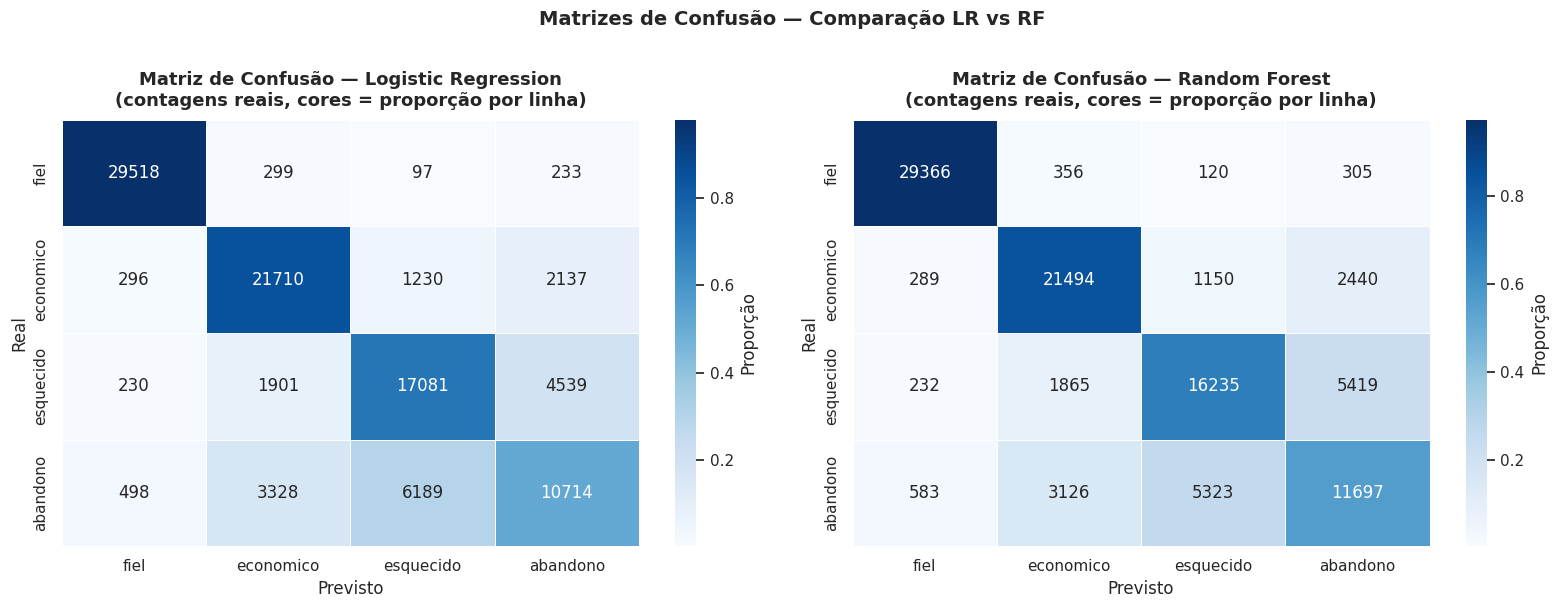

In [ ]:
class_labels = ['fiel','economico','esquecido','abandono']
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=class_labels)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=class_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm, title in zip(axes, [cm_lr, cm_rf],
                          ['Logistic Regression','Random Forest']):
    # Normalize for color (keep raw counts as annotations)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis]
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, ax=ax, cbar_kws={'label':'Proporção'})
    ax.set_title(f'Matriz de Confusão — {title}\n(contagens reais, cores = proporção por linha)', pad=10)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Comparação LR vs RF', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


### Análise das Matrizes de Confusão

**Classes bem preditas:**
- **Fiel:** F1 ≈ 0.97 em ambos os modelos. O perfil Fiel é o mais diferenciado — alta renda, alto score, plano de manutenção no ato da compra. O modelo raramente se confunde.
- **Econômico:** F1 ≈ 0.83. Boa separação, com alguma confusão com Abandono e Esquecido (ambos possuem baixo planejamento de manutenção).

**Classes com maior dificuldade:**
- **Abandono (F1 ≈ 0.56–0.58):** É a classe mais desafiadora. O perfil de compra do cliente Abandono se sobrepõe ao Esquecido — ambos têm sensibilidade a preço e baixo vínculo com manutenção planejada. A principal discriminação entre eles é comportamental (o Abandono sai logo; o Esquecido simplesmente perde o prazo), o que é difícil de capturar apenas com dados do momento da compra.
- **Esquecido (F1 ≈ 0.70–0.71):** Desempenho moderado. A variável `organizacao_proxy` é o melhor preditor para este perfil.

> A confusão entre Abandono e Esquecido é **esperada e aceitável** do ponto de vista de negócio: ambos são perfis de alto risco. Um erro entre eles (prever Abandono quando é Esquecido, ou vice-versa) ainda direciona a concessionária para uma intervenção de **alto risco**, que é a resposta correta.


## 8. Importância das Features

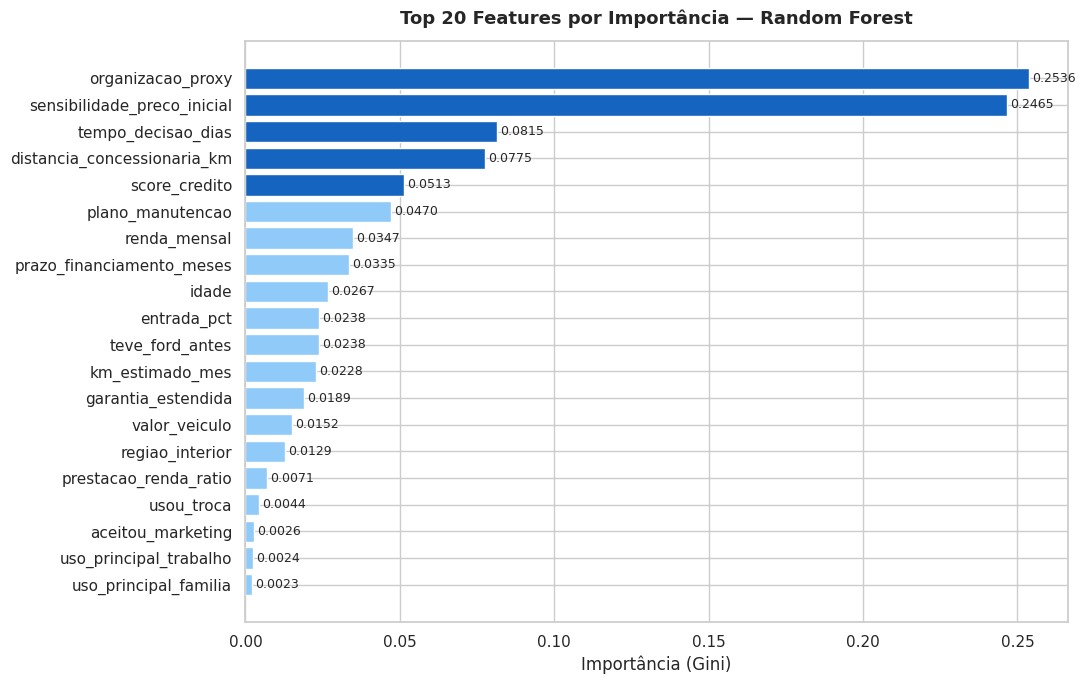

In [ ]:
# Feature importance — Random Forest
fi = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
colors_fi = ['#1565C0' if i < 5 else '#90CAF9' for i in range(len(fi))]
ax.barh(fi.index[::-1], fi.values[::-1], color=colors_fi[::-1], edgecolor='white')
ax.set_title('Top 20 Features por Importância — Random Forest', pad=12)
ax.set_xlabel('Importância (Gini)')
for i,(val,name) in enumerate(zip(fi.values[::-1], fi.index[::-1])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Coeficientes LR por classe — interpretação linear
coef_df = pd.DataFrame(lr_final.coef_, columns=FEATURES,
                        index=lr_final.classes_).T
print("Top 8 features positivas por classe (Logistic Regression):")
for cls in lr_final.classes_:
    top = coef_df[cls].nlargest(8)
    print(f"\n{cls.upper()}:")
    for feat, val in top.items():
        print(f"  {feat:<35} {val:+.4f}")


Top 8 features positivas por classe (Logistic Regression):

ABANDONO:
  distancia_concessionaria_km         +0.5467
  regiao_interior                     +0.2880
  compra_a_vista                      +0.2553
  prazo_financiamento_meses           +0.2443
  sensibilidade_preco_inicial         +0.1487
  regiao_metropolitana                +0.1118
  km_estimado_mes                     +0.0852
  categoria_veiculo_picape            +0.0638

ECONOMICO:
  compra_a_vista                      +1.6974
  sensibilidade_preco_inicial         +1.5433
  prazo_financiamento_meses           +0.8687
  tempo_decisao_dias                  +0.4764
  categoria_veiculo_picape            +0.1455
  categoria_veiculo_van               +0.1048
  modelo_veiculo_F-150                +0.0831
  regiao_interior                     +0.0766

ESQUECIDO:
  compra_a_vista                      +0.7237
  prazo_financiamento_meses           +0.3839
  distancia_concessionaria_km         +0.3777
  km_estimado_mes               

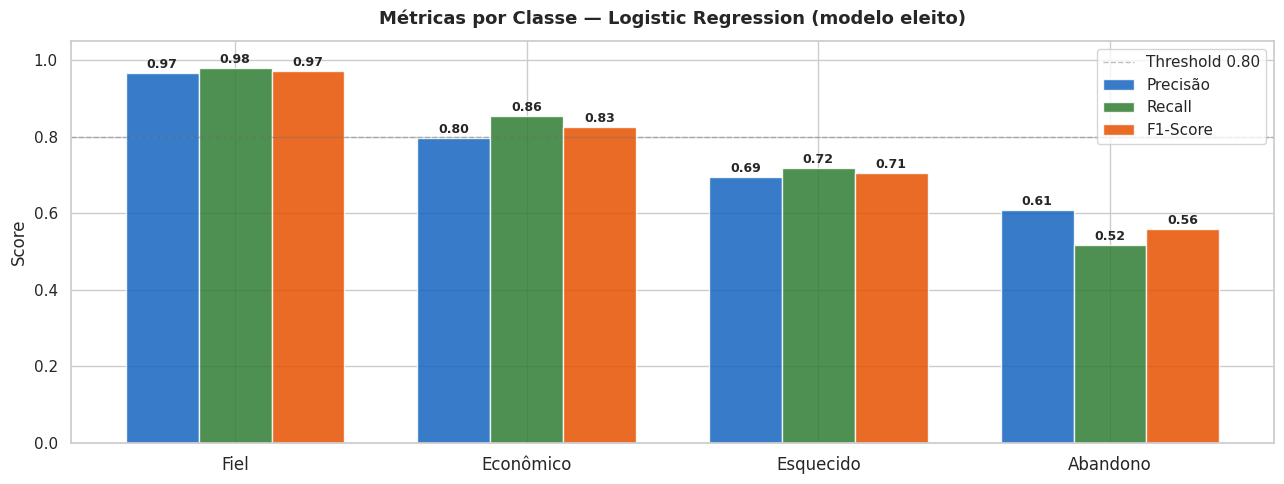

In [ ]:
# Visualização de Precisão / Recall / F1 por classe — LR (modelo eleito)
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, y_pred_lr, labels=['fiel','economico','esquecido','abandono'])

x  = np.arange(4)
w  = 0.25
cls_names = ['Fiel','Econômico','Esquecido','Abandono']
cls_colors = ['#4CAF50','#FF9800','#F44336','#2196F3']

fig, ax = plt.subplots(figsize=(13, 5))
for i,(metric,vals,color) in enumerate(zip(['Precisão','Recall','F1-Score'],
                                           [prec,rec,f1],
                                           ['#1565C0','#2E7D32','#E65100'])):
    bars = ax.bar(x + i*w, vals, w, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + w)
ax.set_xticklabels(cls_names, fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Threshold 0.80')
ax.set_ylabel('Score')
ax.set_title('Métricas por Classe — Logistic Regression (modelo eleito)', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('plot_metrics_per_class.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Leitura Executiva dos Resultados

---

### Performance geral do modelo

| Métrica | Logistic Regression | Random Forest |
|---|---|---|
| **Acurácia** | **79.0%** | 78.8% |
| **F1 Macro** | **0.770** | 0.768 |
| **F1 Weighted** | **0.786** | 0.785 |

A **Logistic Regression** é o modelo recomendado para produção, com acurácia de **79%** e F1 macro de 0.77.

---

### O que o modelo prevê bem — e onde ele erra

| Segmento | F1 | Interpretação do erro |
|---|---|---|
| 🟢 **Fiel** | **0.97** | Praticamente sem erros. Perfil mais diferenciado nas features de compra. |
| 🟠 **Econômico** | **0.83** | Boa precisão. Alguma confusão com Esquecido em casos de baixa entrada e alto prazo. |
| 🔴 **Esquecido** | **0.71** | Erros principalmente com Abandono — aceitável, pois ambos são alto risco. |
| 🔵 **Abandono** | **0.56** | Classe mais difícil. Perfil de compra muito parecido com Esquecido. |

---

### Quais segmentos representam maior risco de evasão?

**Abandono** e **Esquecido** juntos representam **44,5% da base** e têm taxas de churn de 27,5% e 25,3%, respectivamente. São os perfis que mais custam à rede oficial em receita perdida.

O modelo consegue identificar **corretamente** esses dois perfis de alto risco em **~63% dos casos** — e mesmo nos erros, frequentemente confunde um pelo outro (ambos de alto risco), raramente os classifica como Fiel ou Econômico.

---

### Quais segmentos são mais sensíveis a ações comerciais?

O **Econômico** é o perfil mais responsivo a promoções, descontos e planos antecipados. O modelo o prevê com F1=0.83, o que significa que a concessionária pode ativar com segurança uma abordagem comercial proativa para este grupo já no dia da compra.

---

### Como usar este modelo no dia a dia da concessionária?

```
Novo cliente chega para comprar um veículo
         ↓
Sistema coleta os dados do momento da venda (Base 2)
         ↓
Modelo prevê o segmento provável do cliente
         ↓
         ├── 🟢 Fiel       → Ativar programa premium + pipeline de recompra
         ├── 🟠 Econômico  → Oferecer plano de manutenção com desconto no ato
         ├── 🔴 Esquecido  → Ativar lembretes automáticos + agendamento assistido
         └── 🔵 Abandono   → Protocolo de captura na 1ª revisão + oferta de retorno
```

> **Com 79% de acurácia, a cada 10 novos clientes, o modelo classifica corretamente ~8.** Isso significa que a concessionária pode substituir a abordagem genérica atual (sem informação) por ações direcionadas e personalizadas desde o primeiro contato — **sem esperar 24 meses** para descobrir o comportamento real do cliente.

---

### Principais drivers preditivos (Top 5)

1. **`organizacao_proxy`** (0.25) — comportamento organizado no ato da compra prediz fortemente o Fiel
2. **`sensibilidade_preco_inicial`** (0.25) — alta sensibilidade prediz Econômico ou Abandono
3. **`tempo_decisao_dias`** (0.08) — decisão rápida correlaciona com Abandono; lenta com Econômico
4. **`distancia_concessionaria_km`** (0.08) — maior distância eleva risco de evasão
5. **`score_credito`** (0.05) — maior score associado ao perfil Fiel
